In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import auc

In [7]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent.parent))
from config import raw_data, control_data, external_data, raw_kyiv, filtered_data, daily_data

In [8]:
war_date = pd.to_datetime('2022-02-24')
window = 6  
pre_start = war_date - pd.DateOffset(months=window)
post_end = war_date + pd.DateOffset(months=window)

In [9]:
exclude_donors = [
    '06b923ca-4d2d-44bb-8b20-4e2c9b08ce9f',
    '179bbc95-ec8b-4a65-98c5-5d3b566806fa'
]

In [10]:
metrics = {
    "Messages": ("donor_daily_message_count", daily_data / "donor_daily_message_count.csv"),
    "Active_chats": ("daily_active_chats", daily_data / "daily_active_chats.csv"),
    "Active_hours": ("donor_daily_active_hours", daily_data / "donor_daily_active_hours.csv"),
    "Word_count": ("donor_daily_word_count", daily_data / "donor_daily_word_count.csv"),
    "Reactions": ("donor_daily_reaction_count", daily_data / "donor_daily_reactions.csv"),
    "Comments": ("donor_daily_comment_count", daily_data / "donor_daily_comments.csv")
}

In [11]:
def load_and_prepare(col, fpath):
    df = pd.read_csv(fpath)
    df['date'] = pd.to_datetime(df['date'])
    df = df[~df['donation_id'].isin(exclude_donors)]
    df = df[(df['date'] >= pre_start) & (df['date'] <= post_end)]
    return df

above-average (> 0.5)

In [12]:
def compute_above_average(df, col):
    df = df.copy()
    df['percentile'] = df.groupby('donation_id')[col].rank(pct=True)
    df['above_avg'] = (df['percentile'] > 0.5).astype(int)
    return df

In [13]:
def compute_sar_curve(df, period):
    if period == 'pre':
        df_p = df[df['date'] < war_date]
    else:
        df_p = df[df['date'] >= war_date]

    n_donors = df_p['donation_id'].nunique()

    daily_frac = df_p.groupby('date')['above_avg'].mean()

    thresholds = np.linspace(0, 1, 101)
    sar = [( daily_frac >= t).mean() for t in thresholds]

    return thresholds, np.array(sar)

In [14]:
def compute_auc_from_curve(thresholds, sar):
    return auc(thresholds, sar)

#### Choose feature

In [15]:
example_label = 'Active_chats' #change here
example_col, example_path = metrics[example_label]

df_ex = load_and_prepare(example_col, example_path)
df_ex = compute_above_average(df_ex, example_col)

print(f'Donors: {df_ex["donation_id"].nunique()}')
print(f'Days pre: {df_ex[df_ex["date"] < war_date]["date"].nunique()}')
print(f'Days post: {df_ex[df_ex["date"] >= war_date]["date"].nunique()}')


Donors: 22
Days pre: 184
Days post: 182


In [16]:
thresh_pre, sar_pre = compute_sar_curve(df_ex, 'pre')
thresh_post, sar_post = compute_sar_curve(df_ex, 'post')

auc_pre = compute_auc_from_curve(thresh_pre, sar_pre)
auc_post = compute_auc_from_curve(thresh_post, sar_post)

print(f'AUC pre: {auc_pre:.4f}')
print(f'AUC post: {auc_post:.4f}')
print(f'Difference: {auc_post - auc_pre:+.4f}')


AUC pre: 0.4677
AUC post: 0.5251
Difference: +0.0574


#### SAR curve pre vs post (single feature)

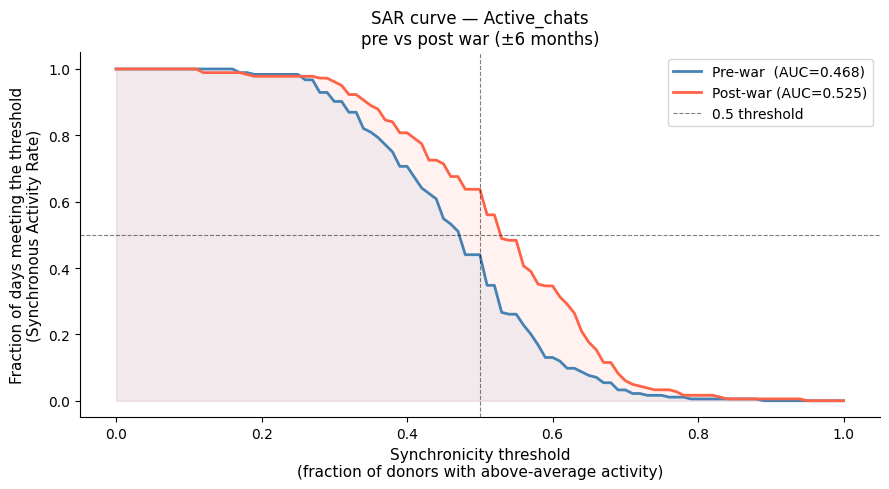

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(thresh_pre, sar_pre, color='steelblue', linewidth=2, label=f'Pre-war  (AUC={auc_pre:.3f})')

ax.plot(thresh_post, sar_post, color='tomato', linewidth=2, label=f'Post-war (AUC={auc_post:.3f})')

ax.axvline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5,
           label='0.5 threshold')
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

ax.fill_between(thresh_pre, sar_pre, alpha=0.08, color='steelblue')
ax.fill_between(thresh_post, sar_post, alpha=0.08, color='tomato')

ax.set_xlabel('Synchronicity threshold\n(fraction of donors with above-average activity)', fontsize=11)
ax.set_ylabel('Fraction of days meeting the threshold\n(Synchronous Activity Rate)', fontsize=11)
ax.set_title(f'SAR curve — {example_label}\npre vs post war (±{window} months)', fontsize=12)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


#### All metrics - AUC pre vs post

In [18]:
auc_results = []

for label, (col, fpath) in metrics.items():
    df_m = load_and_prepare(col, fpath)
    df_m = compute_above_average(df_m, col)

    t_pre, s_pre = compute_sar_curve(df_m, 'pre')
    t_post, s_post = compute_sar_curve(df_m, 'post')

    a_pre = compute_auc_from_curve(t_pre, s_pre)
    a_post = compute_auc_from_curve(t_post, s_post)

    auc_results.append({
        'Feature': label,
        'AUC pre': round(a_pre,  4),
        'AUC post': round(a_post, 4),
        'Delta': round(a_post - a_pre, 4),
    })

auc_df = pd.DataFrame(auc_results)
print(auc_df.to_string(index=False))


     Feature  AUC pre  AUC post   Delta
    Messages   0.4832    0.5196  0.0364
Active_chats   0.4677    0.5251  0.0574
Active_hours   0.4896    0.5073  0.0177
  Word_count   0.4777    0.5266  0.0490
   Reactions   0.4775    0.5279  0.0504
    Comments   0.3195    0.2817 -0.0378


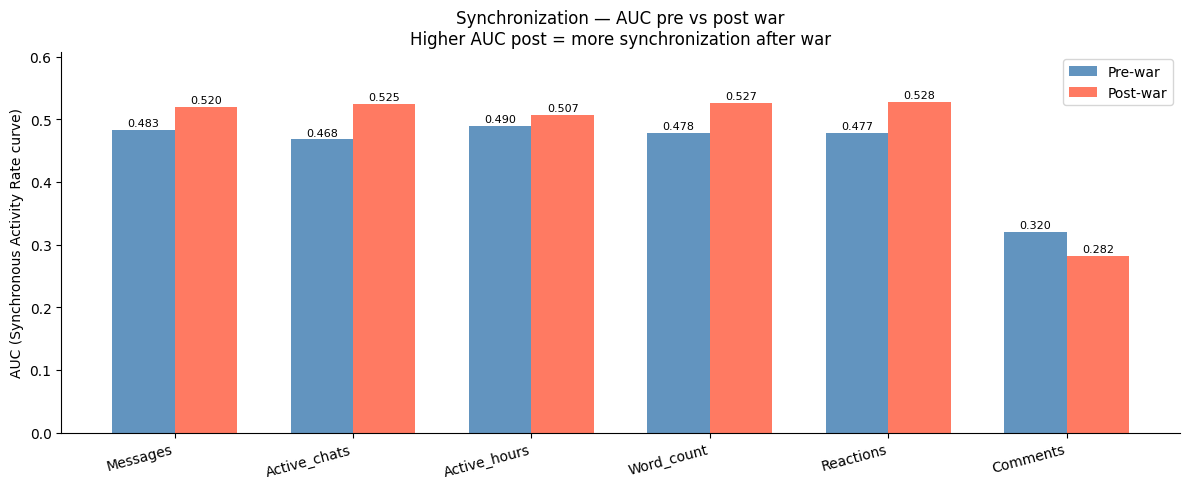

In [19]:
x = np.arange(len(auc_df))
w = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars_pre = ax.bar(x - w/2, auc_df['AUC pre'], w, label='Pre-war',  color='steelblue', alpha=0.85)
bars_post = ax.bar(x + w/2, auc_df['AUC post'], w, label='Post-war', color='tomato', alpha=0.85)

for bar in bars_pre:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars_post:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(auc_df['Feature'], rotation=15, ha='right')
ax.set_ylabel('AUC (Synchronous Activity Rate curve)')
ax.set_title('Synchronization — AUC pre vs post war\nHigher AUC post = more synchronization after war',
             fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, auc_df[['AUC pre','AUC post']].values.max() * 1.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
